In [137]:
import numpy as np 
from sklearn import datasets
import sklearn
import matplotlib.pyplot as plt
from sklearn import metrics, svm
from sklearn.datasets import load_digits
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [126]:
digits = datasets.load_digits()         #download the data 
print(digits.images.shape)
print(digits.keys())


(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


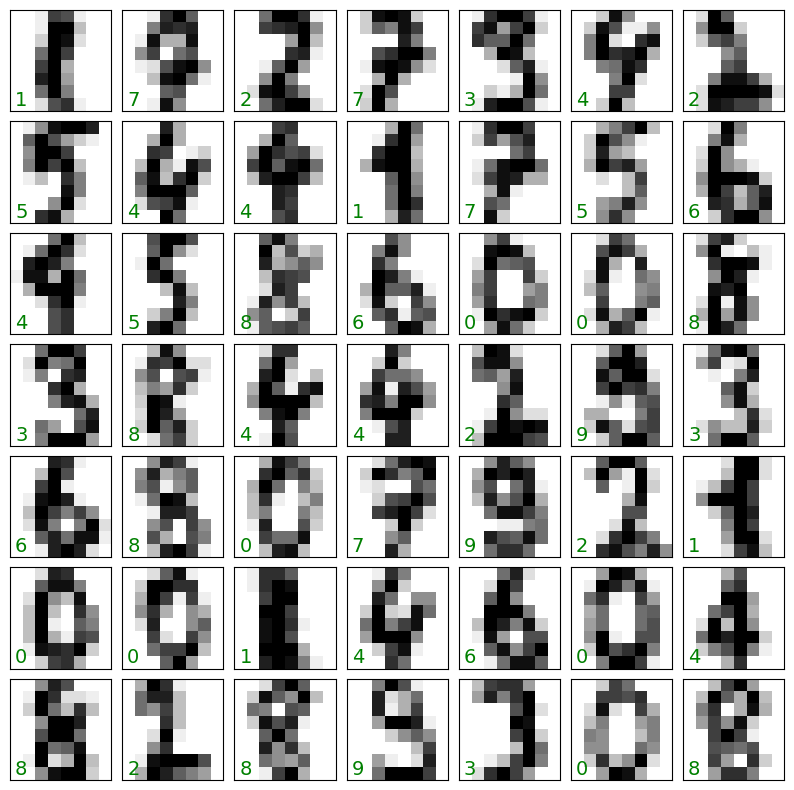

In [127]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [128]:
print(digits.data.shape)

# The images themselves
print(digits.images[1]) #of the 2nd image 

# The data for use in our algorithms
print(digits.data[1])

# The labels
print(digits.target)
print(digits.target[1])


(1797, 64)
[[ 0.  0.  0. 12. 13.  5.  0.  0.]
 [ 0.  0.  0. 11. 16.  9.  0.  0.]
 [ 0.  0.  3. 15. 16.  6.  0.  0.]
 [ 0.  7. 15. 16. 16.  2.  0.  0.]
 [ 0.  0.  1. 16. 16.  3.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  0. 11. 16. 10.  0.  0.]]
[ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
  3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
 16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
  0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
[0 1 2 ... 8 9 8]
1


In [129]:
N=4 #number of dimensions 
embedding = sklearn.manifold.Isomap(n_components=N, n_neighbors=10)
data_red = embedding.fit_transform(digits.data)
data_red.shape


(1797, 4)

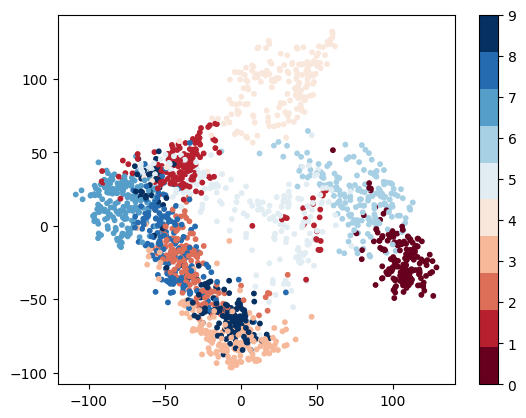

In [130]:
cmap = plt.get_cmap('RdBu', 10)
plt.scatter(data_red[:, 0], data_red[:, 1], cmap=cmap ,c=digits.target, s=10)
plt.colorbar()

In [134]:
#X_train, X_test = train_test_split(data_red, test_size=0.2, random_state=16) #test size is 20% of the data

X_train, X_test, y_train, y_test = train_test_split(data_red, digits.target, test_size=0.2, random_state=16)


Let's try with the TRAIN SET 

In [135]:
clf = LogisticRegression(random_state=0,solver='sag', max_iter=10000).fit(X_train, y_train)    # In roder to converge it uses an high number of iterations

y_pred_train=clf.predict(X_train)           #in this way i find the predicted labels for the training set
acc=accuracy_score(y_train, y_pred_train)

print(acc)
print(clf.score(X_train, y_train)) #accuracy and score are the same thing 


0.9436325678496869
0.9436325678496869


Let's try with the TEST 

In [136]:
y_pred_test=clf.predict(X_test)           #in this way i find the predicted labels for the training set
acc2=accuracy_score(y_test, y_pred_test)

print(acc2)
print(clf.score(X_test, y_test)) #accuracy and score are the same thing 

0.9416666666666667
0.9416666666666667


Confusion matrix:
[[1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.88513514 0.02702703 0.         0.00675676 0.
  0.00675676 0.05405405 0.02027027 0.        ]
 [0.         0.01408451 0.98591549 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.87671233 0.         0.00684932
  0.         0.01369863 0.0890411  0.01369863]
 [0.         0.00704225 0.         0.         0.97183099 0.
  0.         0.         0.         0.02112676]
 [0.         0.00657895 0.         0.         0.         0.98684211
  0.         0.         0.         0.00657895]
 [0.         0.00684932 0.         0.         0.         0.
  0.99315068 0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.96296296 0.00740741 0.02962963]
 [0.         0.04347826 0.         0.04347826 0.         0.00724638
  0.         0.02173913 0.87681159 0.00724

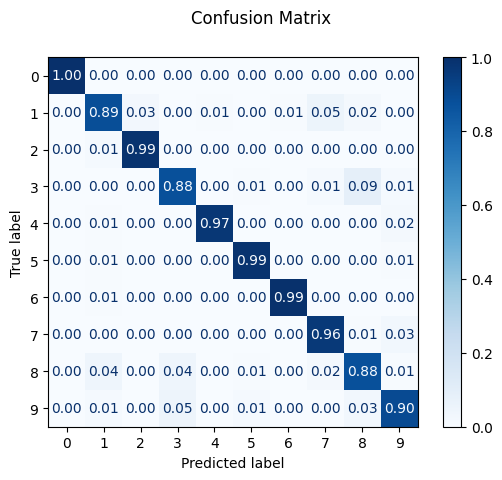

In [149]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train,
                                                        cmap=plt.cm.Blues,
                                                        normalize='true',
                                                        display_labels=digits.target_names, values_format='.2f')
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

Confusion matrix:
[[1.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.82352941 0.         0.         0.         0.
  0.02941176 0.11764706 0.02941176 0.        ]
 [0.         0.05714286 0.94285714 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.02702703 0.         0.         0.83783784 0.         0.
  0.         0.         0.05405405 0.08108108]
 [0.         0.02564103 0.         0.         0.97435897 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         1.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.97727273 0.         0.02272727]
 [0.         0.05555556 0.         0.05555556 0.         0.
  0.         0.         0.88888889 0.        ]
 [0.         0.    

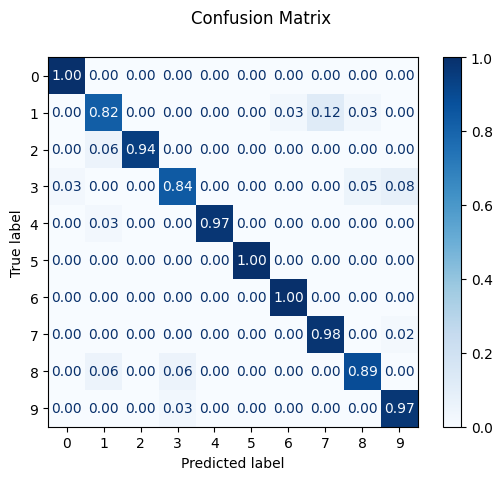

In [150]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test,
                                                        cmap=plt.cm.Blues,
                                                        normalize='true',
                                                        display_labels=digits.target_names, values_format='.2f')
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()